## SAM 3 Propagation Methods — Comparison

Compares two mask-propagation strategies that differ in **how multi-frame information is combined** when more than one starting frame is available:

| Method | Starting frames | Combination strategy |
|--------|----------------|----------------------|
| **Method A** | 1 (single reference) | Bi-directional propagation from one GT seed |
| **Method B** | N (user-selected) | SAM 3 native multi-frame conditioning — all GT seeds loaded before propagation begins, so every frame attends to all anchors simultaneously |

**Goal**: determine whether providing multiple annotated reference frames improves propagation quality (IoU) compared to using a single reference frame.

**Evaluation**:
- Average IoU across all annotated frames  
- Per-frame IoU curve (frame number vs IoU) for each method  
- Side-by-side red/green/yellow overlay visualisations

> **Note**: annotations are available every 30 frames. If a selected frame number is not in the annotated set, the notebook automatically snaps to the nearest annotated frame and warns you.

## 1. Set-up

In [1]:
using_colab = False

In [2]:
if using_colab:
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib pycocotools
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [93]:
import numpy as np
from pycocotools import mask as mask_util
from PIL import Image
import os
import torch
import random
import json

In [4]:
# Device setup: MPS (macOS) > CUDA > CPU
if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
    torch.autocast('mps', dtype=torch.bfloat16).__enter__()
    print('Using MPS (Metal Performance Shaders) on macOS.')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.autocast('cuda', dtype=torch.bfloat16).__enter__()
    print('Using CUDA.')
else:
    device = torch.device('cpu')
    print('Using CPU.')

torch.inference_mode().__enter__()

Using CUDA.


In [5]:
from sam3.model_builder import build_sam3_video_model

# Build the video model — shared across all propagation methods
sam3_model = build_sam3_video_model()

# Tracker predictor for mask-seeded video propagation
tracker = sam3_model.tracker
tracker.backbone = sam3_model.detector.backbone

/home/3152128/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/3152128/.conda/envs/sam3_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO 2026-03-24 16:27:09,920 1685813 sam3_video_base.py: 125: setting max_num_objects=10000 and num_obj_for_compile=16


### Helper Functions

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['axes.titlesize'] = 11
plt.rcParams['figure.titlesize'] = 11


def snap_to_annotated(frame_num: int, annotated_frame_nums: list, label: str = '') -> int:
    """Return the nearest annotated frame number, with a warning if snapping occurs.

    Parameters
    ----------
    frame_num            : requested frame number (may or may not be annotated)
    annotated_frame_nums : sorted list of annotated frame numbers for this object/camera
    label                : human-readable parameter name used in the warning message

    Returns
    -------
    The annotated frame number closest to ``frame_num``.
    Annotations are spaced ~30 frames apart; the function warns whenever it snaps.
    """
    if frame_num in annotated_frame_nums:
        return frame_num
    ann_arr = np.array(annotated_frame_nums)
    idx     = int(np.argmin(np.abs(ann_arr - frame_num)))
    nearest = annotated_frame_nums[idx]
    tag     = f' ({label})' if label else ''
    print(
        f'  ⚠️  Frame #{frame_num}{tag} is NOT in the annotated set '
        f'(annotations every ~30 frames).\n'
        f'       Snapping to nearest annotated frame: #{nearest}  '
        f'(Δ = {abs(nearest - frame_num)} frames).'
    )
    return nearest


def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    """Pixel-level IoU between two boolean arrays (auto-resizes pred to gt shape)."""
    if pred.shape != gt.shape:
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8) * 255).resize(
                (gt.shape[1], gt.shape[0]), Image.NEAREST
            )
        ) > 127
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else 0.0


def decode_mask(rle, H: int, W: int) -> np.ndarray:
    """Decode a COCO RLE mask and resize to (H, W) if needed."""
    m = mask_util.decode(rle).astype(bool)
    if m.shape != (H, W):
        m = np.array(
            Image.fromarray(m.astype(np.uint8) * 255).resize((W, H), Image.NEAREST)
        ) > 127
    return m


def render_overlay(rgb: np.ndarray, pred: np.ndarray, gt: np.ndarray,
                   alpha: float = 0.45) -> np.ndarray:
    """Blend pred (red), gt (green), overlap (yellow) onto an RGB frame copy."""
    img = rgb.copy().astype(np.float32)
    if pred.shape != (rgb.shape[0], rgb.shape[1]):
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8) * 255).resize(
                (rgb.shape[1], rgb.shape[0]), Image.NEAREST
            )
        ) > 127
    overlap   = pred & gt
    pred_only = pred & ~overlap
    gt_only   = gt  & ~overlap
    for mask, colour in [
        (gt_only,   np.array([0,   200,   0], dtype=np.float32)),
        (pred_only, np.array([220,   0,   0], dtype=np.float32)),
        (overlap,   np.array([255, 220,   0], dtype=np.float32)),
    ]:
        img[mask] = img[mask] * (1 - alpha) + colour * alpha
    return img.clip(0, 255).astype(np.uint8)


def plot_methods(seq_idx, frame_num, method_results, gt, rgb, seed_frame_nums=None):
    """Side-by-side overlay plot for a single frame across all methods.

    Parameters
    ----------
    method_results  : list of (label, pred_mask, iou) tuples
    seed_frame_nums : set of frame numbers used as seeds (marked in the title)
    """
    seed_frame_nums = seed_frame_nums or set()
    n = len(method_results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (label, pred, iou) in zip(axes, method_results):
        ax.imshow(render_overlay(rgb, pred, gt))
        ax.set_title(f'{label}\n(IoU = {iou:.3f})')
        ax.axis('off')
    axes[-1].legend(
        handles=[
            mpatches.Patch(color=(0, 200/255, 0),   label='GT only'),
            mpatches.Patch(color=(220/255, 0, 0),    label='Pred only'),
            mpatches.Patch(color=(1.0, 220/255, 0),  label='Overlap'),
        ],
        loc='lower right', fontsize=8,
    )
    markers = []
    if frame_num == ref_fn:
        markers.append('primary seed')
    if frame_num in seed_frame_nums and frame_num != ref_fn:
        markers.append('Method B seed')
    tag = f'  ← {", ".join(markers)}' if markers else ''
    fig.suptitle(f'Frame #{frame_num}  (seq {seq_idx}){tag}', y=1.01)
    plt.tight_layout()
    plt.show()

## 2. Configuration

Run the three sub-steps in order.  
Each step prints information that guides the choices in the next step.

### 2.1 — Data path

Set the root data directory and take ID, then run the cell to see **all available objects and cameras** in this take.

In [89]:
DATA_DIR = '../data/test_mask_prop/'
TAKE_UID = '8acb2112-465c-4088-b502-65fd9704dd77'   # change to your take

ann_path = os.path.join(DATA_DIR, TAKE_UID, 'annotation.json')
with open(ann_path) as f:
    ann = json.load(f)

masks_by_obj = ann['masks']  # {object_name: {camera: {frame_str: rle}}}

# ── Print summary table ───────────────────────────────────────────────────────
print(f'Take : {TAKE_UID}')
print(f'{"Object":<35}  {"Camera":<25}  {"Frames":>7}')
print('-' * 72)
for obj, cams in masks_by_obj.items():
    for cam, frames in cams.items():
        print(f'{obj:<35}  {cam:<25}  {len(frames):>7}')

Take : 8acb2112-465c-4088-b502-65fd9704dd77
Object                               Camera                      Frames
------------------------------------------------------------------------
noodles package_0                    aria01_214-1                   316
noodles_0                            gp03                           254
noodles_0                            aria01_214-1                   288
salt container _0                    gp02                          1070
salt container _0                    aria01_214-1                   837
black saucepan _0                    gp03                          1065
black saucepan _0                    aria01_214-1                   759
glass mug_0                          aria01_214-1                   749
glass mug_0                          gp04                          1014
cooked noodles_0                     gp04                            33
cooked noodles_0                     aria01_214-1                    25
noodles package_1  

### 2.2 — Object & camera selection

Pick an object and camera from the table above, then run the cell to see **per-frame mask coverage** for your selection.

In [90]:
OBJECT_NAME = 'black saucepan _0'    # ← pick from the table above
CAMERA      = 'aria01_214-1'         # ← pick from the table above

assert OBJECT_NAME in masks_by_obj, f'Object "{OBJECT_NAME}" not found. Available: {list(masks_by_obj)}'
assert CAMERA in masks_by_obj[OBJECT_NAME], (
    f'Camera "{CAMERA}" not found for "{OBJECT_NAME}". '
    f'Available: {list(masks_by_obj[OBJECT_NAME])}'
)

frame_dict  = masks_by_obj[OBJECT_NAME][CAMERA]           # {frame_str: rle}
frame_strs  = sorted(frame_dict.keys(), key=int)          # sorted string frame IDs
frame_nums  = [int(f) for f in frame_strs]                # integer frame IDs

# ── Image size (from first frame) ────────────────────────────────────────────
img0 = Image.open(os.path.join(DATA_DIR, TAKE_UID, CAMERA, f'{frame_strs[0]}.jpg'))
W, H = img0.width, img0.height
empty_mask = np.zeros((H, W), dtype=bool)

print(f'Object : {OBJECT_NAME}')
print(f'Camera : {CAMERA}')
print(f'Frames : {len(frame_nums)}  (#{frame_nums[0]} → #{frame_nums[-1]})')
print(f'Size   : {W}×{H} px')

Object : black saucepan _0
Camera : aria01_214-1
Frames : 759  (#240 → #31860)
Size   : 448×448 px


### 2.3 — Experiment settings

- `STARTING_FRAME_NUM`: primary reference frame (**Method A** seed; also used by Method B).  
  Set `None` to auto-select the frame with the **largest GT mask area**.
- `METHOD_B_EXTRA_FRAME_NUMS`: list of **additional** frame numbers to seed Method B  
  (up to 4 extra, 5 total including the primary). Set `None` to disable Method B.
- `VIS_STRIDE`: show every N-th frame in the side-by-side visualisation.

> **Annotation check**: annotations exist every ~30 frames. If you enter a frame number that  
> is not annotated, `snap_to_annotated()` will automatically redirect you to the nearest  
> annotated frame and print a warning — no crash, no silent wrong result.

In [97]:
# Primary reference frame — set to None to auto-select the frame with the largest GT mask
STARTING_FRAME_NUM = 24630

# Method B: additional reference frame numbers (the primary ref is always included).
# Set to None to disable Method B, or provide a list of 1–4 extra frame numbers.
# Frames do NOT need to be exactly annotated — snap_to_annotated() will warn and
# round to the nearest annotated frame automatically.
METHOD_B_EXTRA_FRAME_NUMS = [3990, 25020]   # e.g. [5120, 18340, 27900]
METHOD_B_EXTRA_FRAME_NUMS_RANDOM = random.sample(frame_nums, k=3)
# Show every N-th annotated frame in the side-by-side visualisation
VIS_STRIDE = 50

# ── Resolve primary reference frame ──────────────────────────────────────────
if STARTING_FRAME_NUM is None:
    _sizes = {
        fn: decode_mask(frame_dict[fstr], H, W).sum()
        for fstr, fn in zip(frame_strs, frame_nums)
    }
    ref_fn = max(_sizes, key=_sizes.get)
else:
    ref_fn = snap_to_annotated(STARTING_FRAME_NUM, frame_nums, label='STARTING_FRAME_NUM')

ref_seq_idx = frame_nums.index(ref_fn)
ref_fstr    = frame_strs[ref_seq_idx]
ref_gt_mask = decode_mask(frame_dict[ref_fstr], H, W)

print(f'Primary reference frame : #{ref_fn}  (seq idx {ref_seq_idx})')
print(f'GT mask area            : {ref_gt_mask.sum():,} px')

# ── Resolve Method B extra frames ────────────────────────────────────────────
if METHOD_B_EXTRA_FRAME_NUMS is not None:
    METHOD_B_EXTRA_FRAME_NUMS = [
        snap_to_annotated(fn, frame_nums, label=f'METHOD_B_EXTRA_FRAME_NUMS[{i}]')
        for i, fn in enumerate(METHOD_B_EXTRA_FRAME_NUMS)
    ]
    print(f'Method B extra frames   : {METHOD_B_EXTRA_FRAME_NUMS}')
    print(f'Method B random extra frames   : {METHOD_B_EXTRA_FRAME_NUMS_RANDOM}')

Primary reference frame : #24630  (seq idx 577)
GT mask area            : 6,693 px
Method B extra frames   : [3990, 25020]
Method B random extra frames   : [4410, 21720, 25290]


## 3. Load Data

Loads all RGB frames and GT masks for the selected object, camera, and take.

Loading 759 frames and GT masks...
  loaded 100/759 frames
  loaded 200/759 frames
  loaded 300/759 frames
  loaded 400/759 frames
  loaded 500/759 frames
  loaded 600/759 frames
  loaded 700/759 frames
  loaded 759/759 frames


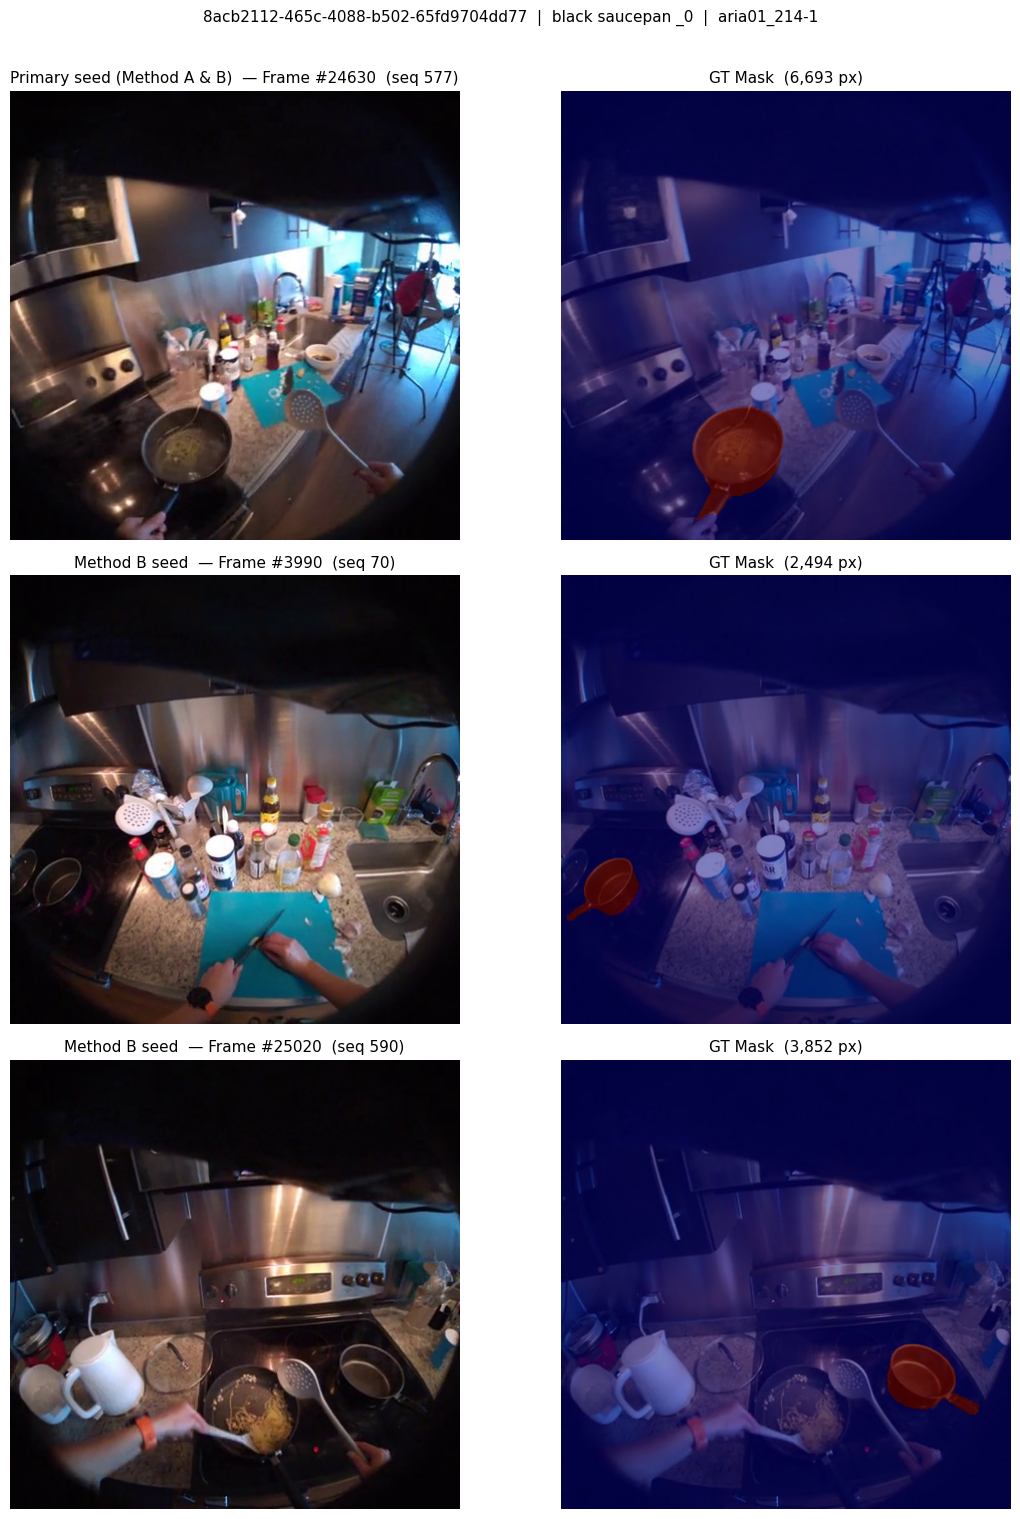

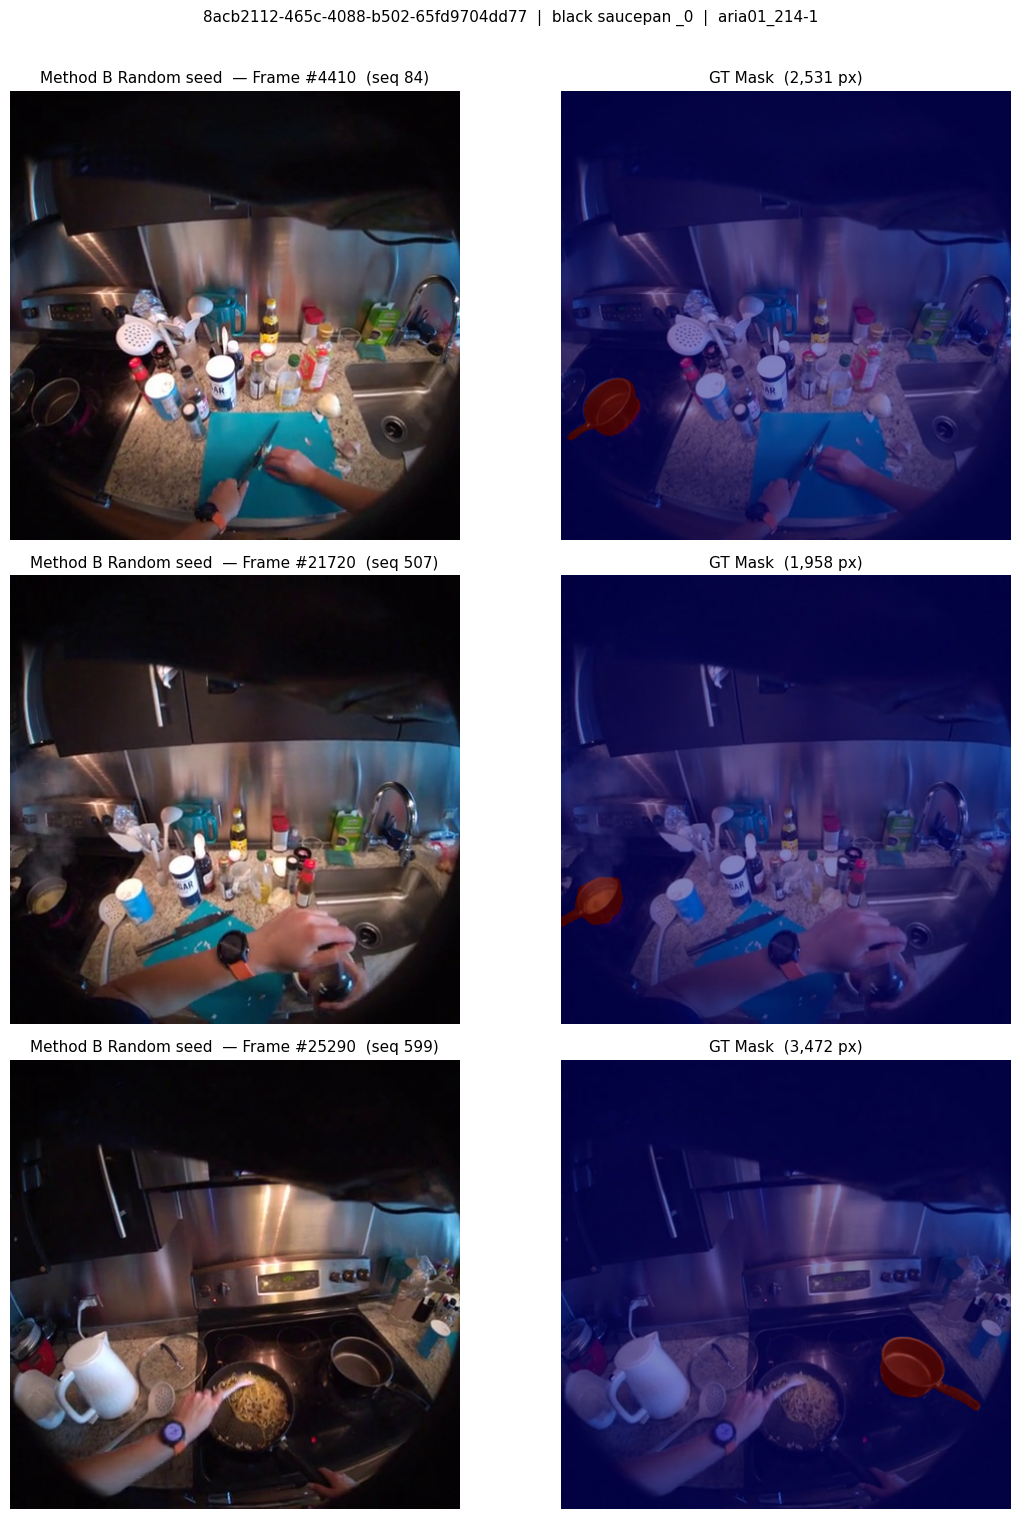

In [99]:
print(f'Loading {len(frame_nums)} frames and GT masks...')

frames_rgb = {}   # frame_num -> np.ndarray (H, W, 3)
gt_masks   = {}   # frame_num -> bool np.ndarray (H, W)

for i, (fstr, fn) in enumerate(zip(frame_strs, frame_nums)):
    # RGB frame
    img_path = os.path.join(DATA_DIR, TAKE_UID, CAMERA, f'{fstr}.jpg')
    frames_rgb[fn] = np.array(Image.open(img_path).convert('RGB'))

    # GT mask (resize to image resolution if stored at a different resolution)
    gt_masks[fn] = decode_mask(frame_dict[fstr], H, W)

    if (i + 1) % 100 == 0 or (i + 1) == len(frame_nums):
        print(f'  loaded {i+1}/{len(frame_nums)} frames')

# ── Collect all seed frames to visualise ─────────────────────────────────────
_b_extra_fns = (
    [fn for fn in METHOD_B_EXTRA_FRAME_NUMS if fn != ref_fn]
    if METHOD_B_EXTRA_FRAME_NUMS is not None else []
)
_b_extra_fns_rnd = (
    [fn for fn in METHOD_B_EXTRA_FRAME_NUMS_RANDOM if fn != ref_fn]
    if METHOD_B_EXTRA_FRAME_NUMS_RANDOM is not None else []
)
_all_seed_fns = [ref_fn] + _b_extra_fns   # primary first, then Method B extras
_all_seed_fns_rnd = _b_extra_fns_rnd  

n_seeds = len(_all_seed_fns)
n_seeds_rnd = len(_all_seed_fns_rnd)

fig, axes = plt.subplots(n_seeds, 2, figsize=(12, 5 * n_seeds), squeeze=False)
for row, fn in enumerate(_all_seed_fns):
    seq_i = frame_nums.index(fn)
    gt_m  = gt_masks[fn]
    label = 'Primary seed (Method A & B)' if fn == ref_fn else f'Method B seed'
    axes[row, 0].imshow(frames_rgb[fn])
    axes[row, 0].set_title(f'{label}  — Frame #{fn}  (seq {seq_i})')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(frames_rgb[fn])
    axes[row, 1].imshow(gt_m, alpha=0.5, cmap='jet')
    axes[row, 1].set_title(f'GT Mask  ({gt_m.sum():,} px)')
    axes[row, 1].axis('off')

fig.suptitle(f'{TAKE_UID}  |  {OBJECT_NAME}  |  {CAMERA}', y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_seeds, 2, figsize=(12, 5 * n_seeds_rnd), squeeze=False)
for row, fn in enumerate(_all_seed_fns_rnd):
    seq_i = frame_nums.index(fn)
    gt_m  = gt_masks[fn]
    label = f'Method B Random seed'
    axes[row, 0].imshow(frames_rgb[fn])
    axes[row, 0].set_title(f'{label}  — Frame #{fn}  (seq {seq_i})')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(frames_rgb[fn])
    axes[row, 1].imshow(gt_m, alpha=0.5, cmap='jet')
    axes[row, 1].set_title(f'GT Mask  ({gt_m.sum():,} px)')
    axes[row, 1].axis('off')

fig.suptitle(f'{TAKE_UID}  |  {OBJECT_NAME}  |  {CAMERA}', y=1.01)
plt.tight_layout()
plt.show()

## 4. Prepare Temp Video Directory

SAM 3's tracker expects a flat directory of sequentially numbered JPEGs.  
We copy the per-camera frames there in sorted order.

In [85]:
import shutil
import tempfile

tmp_video_dir = tempfile.mkdtemp(prefix='sam3_prop_cmp_')

for seq_idx, fstr in enumerate(frame_strs):
    src = os.path.join(DATA_DIR, TAKE_UID, CAMERA, f'{fstr}.jpg')
    dst = os.path.join(tmp_video_dir, f'{seq_idx:05d}.jpg')
    shutil.copy(src, dst)

print(f'Copied {len(frame_strs)} frames → {tmp_video_dir}')

mask_tensor = torch.tensor(ref_gt_mask.astype(np.float32))   # (H, W) float
n_frames    = len(frame_nums)

Copied 220 frames → /home/3152128/.tmp/sam3_prop_cmp__k4z5cgi


## 5. Method A — Basic SAM 3 Bi-directional Propagation

Seed the tracker with the GT mask at the reference frame, then propagate forward and backward and merge the results.

This is the baseline against which all other propagation methods are compared.

In [79]:
def collect_propagation_masks(tracker, inf_state, start_frame_idx, reverse, n_frames):
    """Run propagation and return {seq_idx: bool mask} for all yielded frames."""
    masks = {}
    for frame_idx, _, _, vrm, _ in tracker.propagate_in_video(
        inf_state,
        start_frame_idx=start_frame_idx,
        max_frame_num_to_track=n_frames,
        reverse=reverse,
        propagate_preflight=True,
    ):
        masks[frame_idx] = (vrm[0] > 0.0).cpu().numpy().squeeze()
    return masks


# ── Forward: reference → last frame ──────────────────────────────────────────
inf_state_fwd = tracker.init_state(video_path=tmp_video_dir)
tracker.add_new_mask(inference_state=inf_state_fwd, frame_idx=ref_seq_idx, obj_id=1, mask=mask_tensor)
method_a_fwd = collect_propagation_masks(tracker, inf_state_fwd, ref_seq_idx, reverse=False, n_frames=n_frames)
print(f'Forward:  {len(method_a_fwd)} frames  (seq {min(method_a_fwd)} → {max(method_a_fwd)})')

# ── Backward: reference → first frame ────────────────────────────────────────
inf_state_bwd = tracker.init_state(video_path=tmp_video_dir)
tracker.add_new_mask(inference_state=inf_state_bwd, frame_idx=ref_seq_idx, obj_id=1, mask=mask_tensor)
method_a_bwd = collect_propagation_masks(tracker, inf_state_bwd, ref_seq_idx, reverse=True, n_frames=n_frames)
print(f'Backward: {len(method_a_bwd)} frames  (seq {min(method_a_bwd)} → {max(method_a_bwd)})')

# ── Merge: backward for frames before reference, forward for the rest ─────────
method_a_masks = {
    i: (method_a_bwd if i < ref_seq_idx else method_a_fwd).get(i, empty_mask)
    for i in range(n_frames)
}
print(f'Merged:   {len(method_a_masks)} frames total')

propagate in video: 100%|██████████| 187/187 [00:06<00:00, 27.10it/s]


Forward:  187 frames  (seq 33 → 219)


propagate in video: 100%|██████████| 34/34 [00:01<00:00, 27.72it/s]

Backward: 34 frames  (seq 0 → 33)
Merged:   220 frames total


## 6. Method B — Multi-frame SAM 3 Conditioning

Seed the tracker with GT masks at **multiple reference frames** (the primary ref plus any frames
listed in `METHOD_B_EXTRA_FRAME_NUMS`), then propagate bi-directionally from the earliest seed.

All seeded frames enter `cond_frame_outputs` before propagation starts, so every intermediate
frame attends to all anchors simultaneously (up to the `max_cond_frames_in_attn=4` cap).
This tests whether flanking ground-truth anchors resolve failure cases caused by similar nearby objects.

In [86]:
if METHOD_B_EXTRA_FRAME_NUMS is None:
    print('METHOD_B_EXTRA_FRAME_NUMS is None — skipping Method B.')
    method_b_masks = {i: empty_mask for i in range(n_frames)}
    method_b_label = 'Method B (disabled)'
else:
    # Remove duplicates with the primary ref (snap_to_annotated may have aligned them)
    extra = [fn for fn in METHOD_B_EXTRA_FRAME_NUMS if fn != ref_fn]
    assert len(extra) <= 4, 'At most 4 extra frames (5 total incl. primary)'

    method_b_all_fns  = sorted({ref_fn} | set(extra))
    method_b_seq_idxs = [frame_nums.index(fn) for fn in method_b_all_fns]
    method_b_start    = method_b_seq_idxs[0]   # earliest seed — bidirectional pivot
    method_b_label    = f'Method B — {len(method_b_all_fns)}-frame conditioning'

    print(f'Seeding {len(method_b_all_fns)} reference frames: {method_b_all_fns}')
    print(f'  seq indices : {method_b_seq_idxs}')
    print(f'  pivot (fwd/bwd start) : seq {method_b_start}  frame #{method_b_all_fns[0]}')

    def seed_multi_frame_state(seq_indices):
        """Init inference state and add GT masks at each seq_idx."""
        state = tracker.init_state(video_path=tmp_video_dir)
        for si in seq_indices:
            fn_i = frame_nums[si]
            tracker.add_new_mask(
                inference_state=state,
                frame_idx=si, obj_id=1,
                mask=torch.tensor(gt_masks[fn_i].astype(np.float32)),
            )
        return state

    # ── Forward ──────────────────────────────────────────────────────────────
    inf_state_b_fwd = seed_multi_frame_state(method_b_seq_idxs)
    method_b_fwd    = collect_propagation_masks(
        tracker, inf_state_b_fwd, method_b_start, reverse=False, n_frames=n_frames
    )
    print(f'Forward:  {len(method_b_fwd)} frames  (seq {min(method_b_fwd)} → {max(method_b_fwd)})')

    # ── Backward ─────────────────────────────────────────────────────────────
    inf_state_b_bwd = seed_multi_frame_state(method_b_seq_idxs)
    method_b_bwd    = collect_propagation_masks(
        tracker, inf_state_b_bwd, method_b_start, reverse=True, n_frames=n_frames
    )
    print(f'Backward: {len(method_b_bwd)} frames  (seq {min(method_b_bwd)} → {max(method_b_bwd)})')

    # ── Merge ─────────────────────────────────────────────────────────────────
    method_b_masks = {
        i: (method_b_bwd if i < method_b_start else method_b_fwd).get(i, empty_mask)
        for i in range(n_frames)
    }
    print(f'Merged:   {len(method_b_masks)} frames total')

Seeding 4 reference frames: [1020, 1650, 2190, 6840]
  seq indices : [33, 54, 60, 180]
  pivot (fwd/bwd start) : seq 33  frame #1020


propagate in video: 100%|██████████| 187/187 [00:07<00:00, 26.23it/s]


Forward:  187 frames  (seq 33 → 219)


propagate in video: 100%|██████████| 34/34 [00:01<00:00, 26.15it/s]

Backward: 34 frames  (seq 0 → 33)
Merged:   220 frames total


## 7. IoU Comparison

In [87]:
# ── Register the two methods to evaluate ─────────────────────────────────────
# Each entry: (display label, pred_masks dict {seq_idx: bool mask})
METHODS = [
    ('Method A — Single-frame (baseline)', method_a_masks),
    (method_b_label,                       method_b_masks),
]

# ── Compute per-frame IoU for every method ────────────────────────────────────
iou_per_method = {}   # label -> {frame_num: float}
mean_iou       = {}   # label -> float

for label, pred_masks in METHODS:
    per_frame = {}
    for seq_idx, fn in enumerate(frame_nums):
        per_frame[fn] = compute_iou(pred_masks[seq_idx], gt_masks[fn])
    iou_per_method[label] = per_frame
    mean_iou[label]       = float(np.mean(list(per_frame.values())))

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"Method":<45}  {"Mean IoU":>9}  {"IoU>0.5":>8}  {"IoU>0.75":>9}')
print('-' * 78)
for label, _ in METHODS:
    vals = list(iou_per_method[label].values())
    n    = len(vals)
    gt50 = sum(v > 0.5  for v in vals) / n * 100
    gt75 = sum(v > 0.75 for v in vals) / n * 100
    print(f'{label:<45}  {mean_iou[label]:>9.4f}  {gt50:>7.1f}%  {gt75:>8.1f}%')

Method                                          Mean IoU   IoU>0.5   IoU>0.75
------------------------------------------------------------------------------
Method A — Single-frame (baseline)                0.3841     34.5%      28.6%
Method B — 4-frame conditioning                   0.6986     76.8%      70.5%


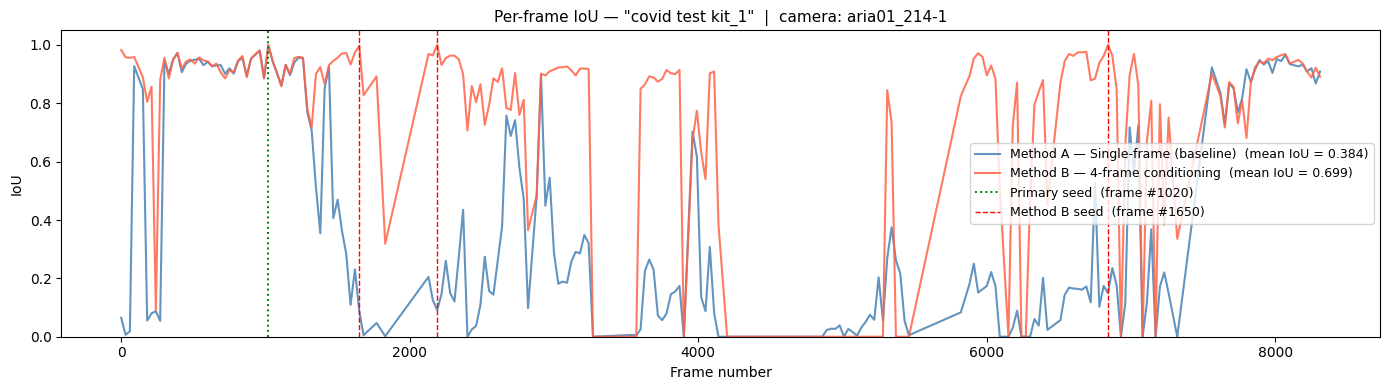

In [88]:
# ── Per-frame IoU curves  (x-axis = actual frame number) ─────────────────────
PALETTE = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']
STYLES  = ['-', '-', '-', '-', (0, (3, 1, 1, 1))]

fig, ax = plt.subplots(figsize=(14, 4))

for (label, _), colour, style in zip(METHODS, PALETTE, STYLES):
    ax.plot(
        frame_nums,
        [iou_per_method[label][fn] for fn in frame_nums],
        label=f'{label}  (mean IoU = {mean_iou[label]:.3f})',
        color=colour, linestyle=style, linewidth=1.5, alpha=0.85,
    )

# Mark primary reference frame
ax.axvline(ref_fn, color='green', linestyle=':', linewidth=1.4,
           label=f'Primary seed  (frame #{ref_fn})')

# Mark Method B extra seed frames (if any)
if METHOD_B_EXTRA_FRAME_NUMS is not None:
    _b_extras = [fn for fn in method_b_all_fns if fn != ref_fn]
    for _i, _fn in enumerate(_b_extras):
        ax.axvline(
            _fn, color='red', linestyle='--', linewidth=1.0,
            label=f'Method B seed  (frame #{_fn})' if _i == 0 else None,
        )

ax.set_xlabel('Frame number')
ax.set_ylabel('IoU')
ax.set_ylim(0, 1.05)
ax.set_title(f'Per-frame IoU — "{OBJECT_NAME}"  |  camera: {CAMERA}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Visualisation — Side-by-side Overlays

Predicted mask = **red** · GT mask = **green** · Overlap = **yellow**  
Frames are shown every `VIS_STRIDE` annotated frame step(s).

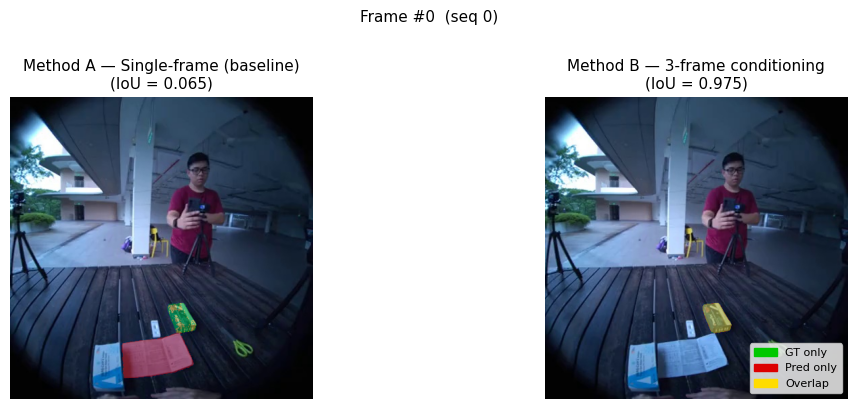

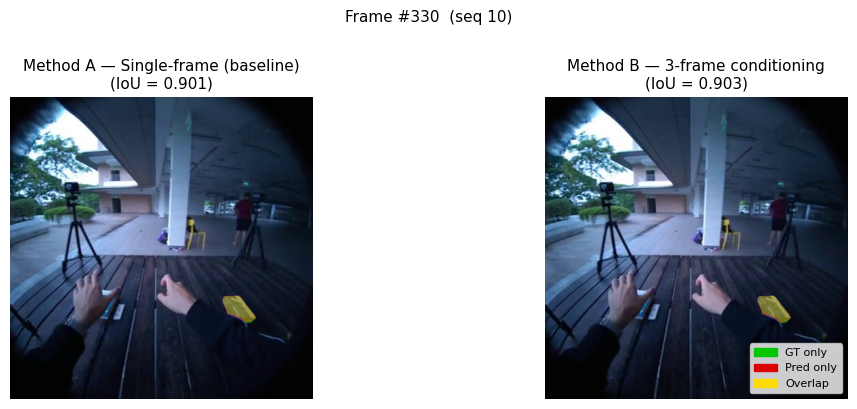

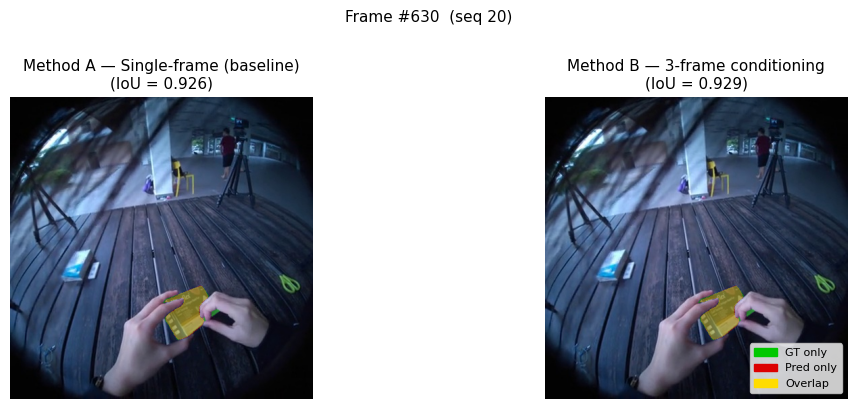

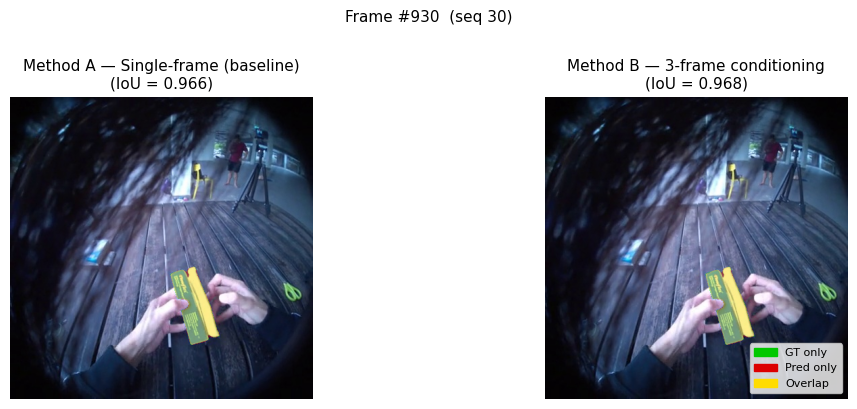

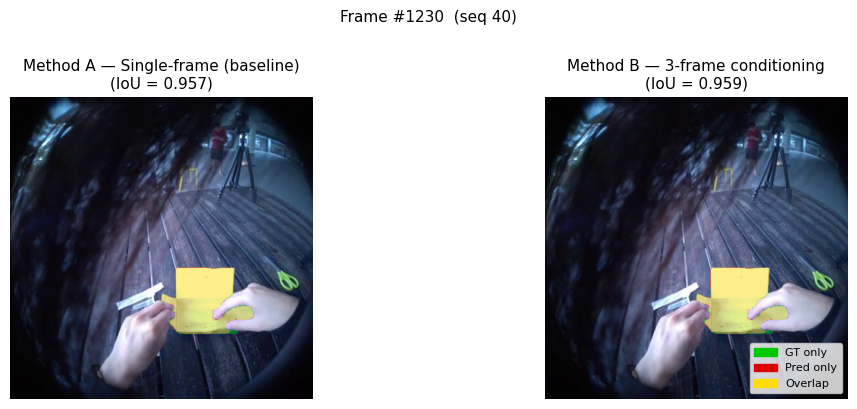

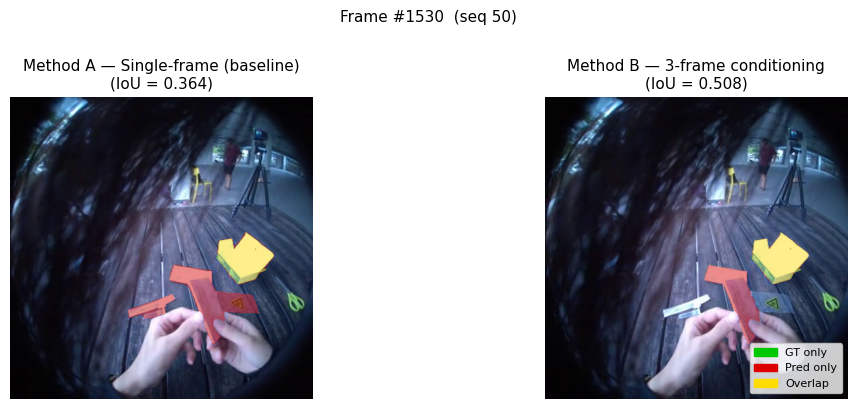

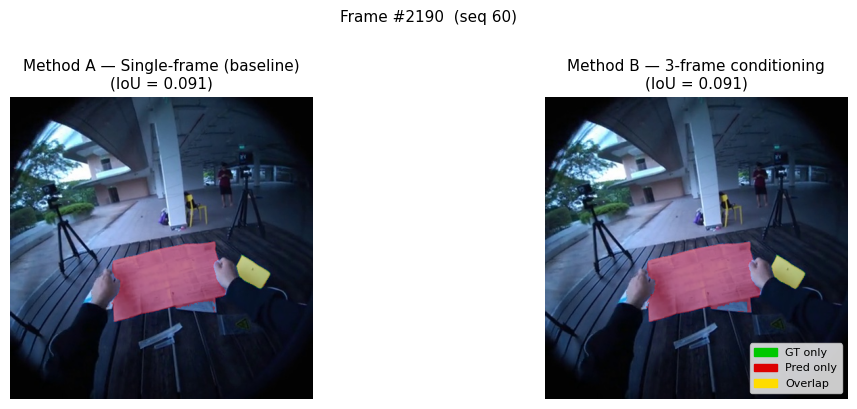

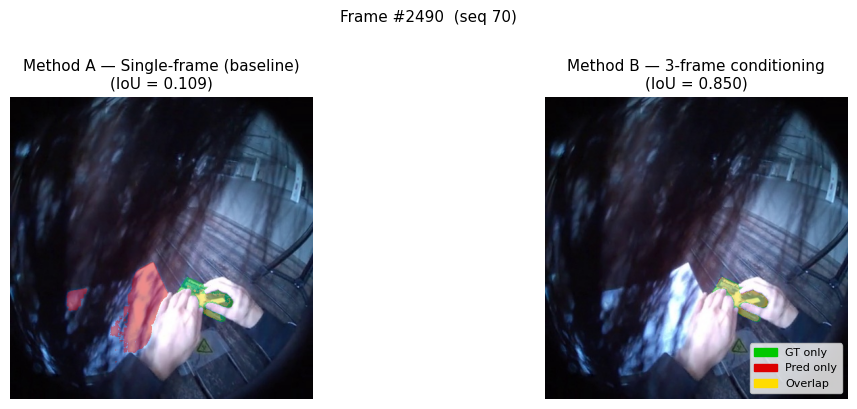

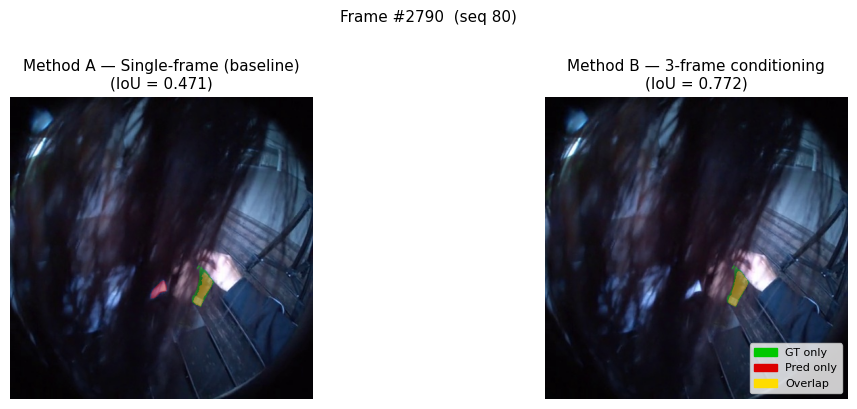

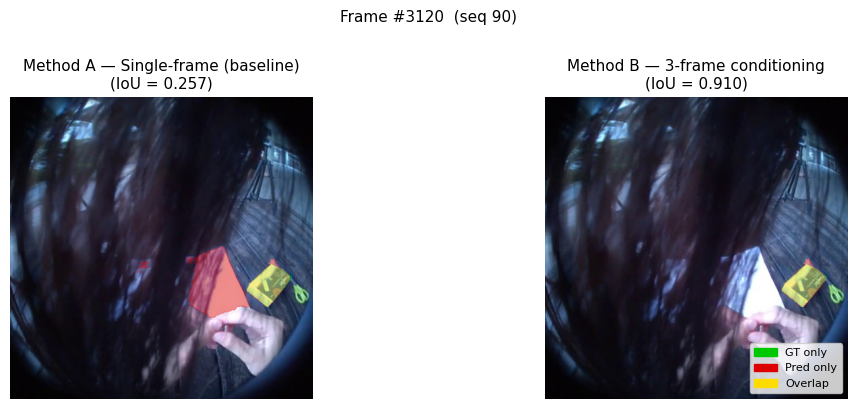

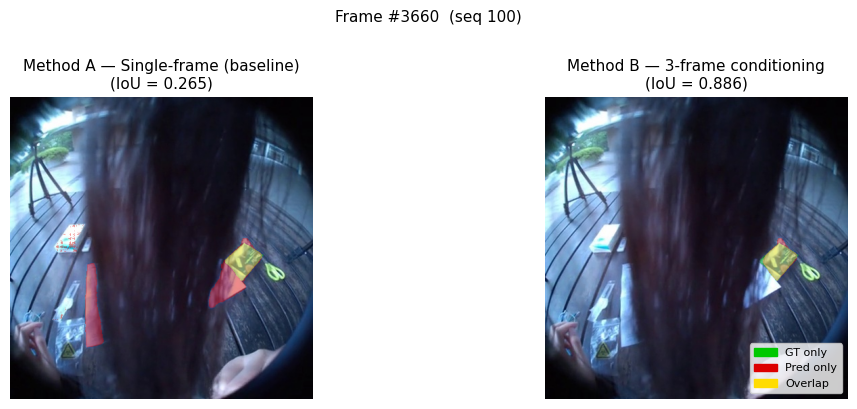

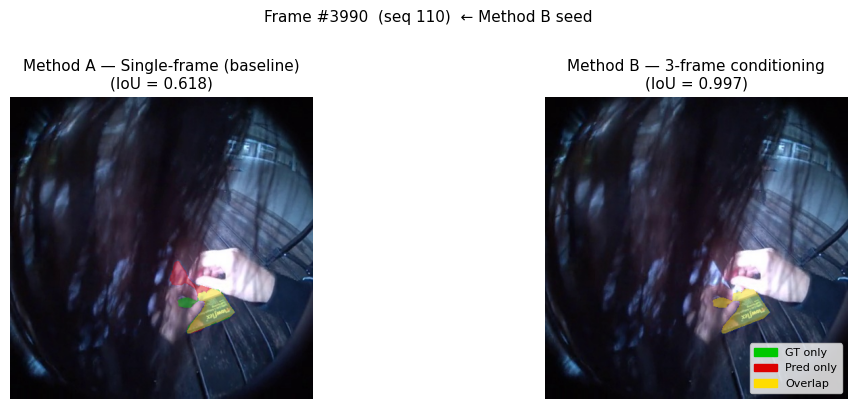

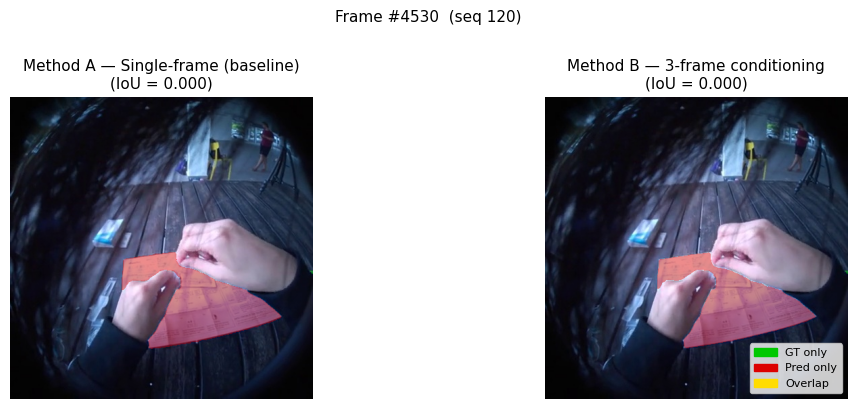

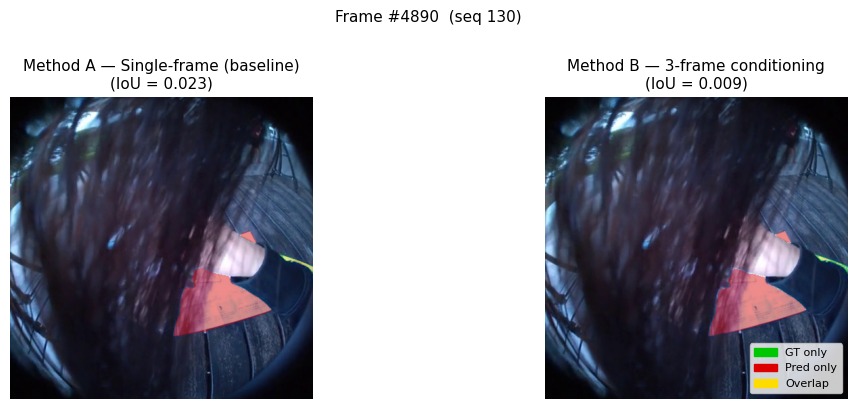

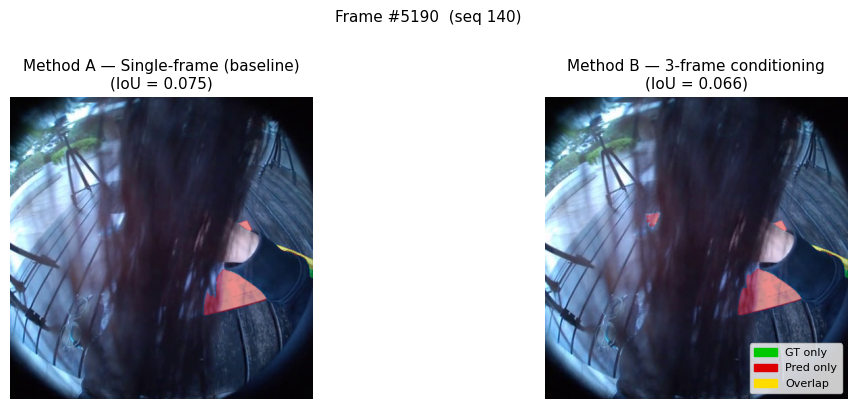

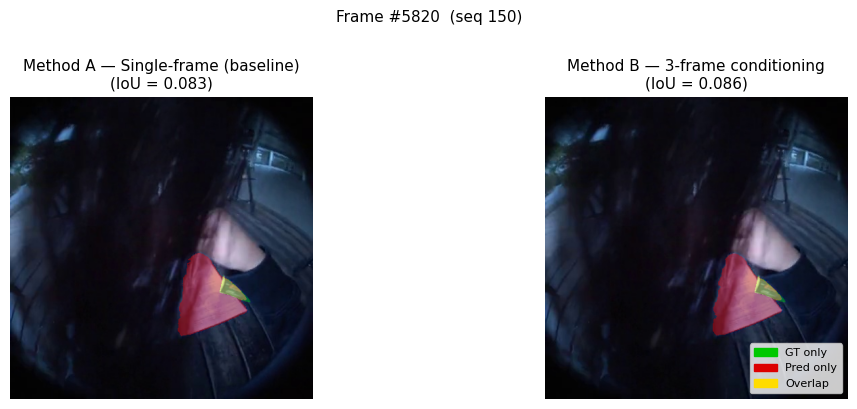

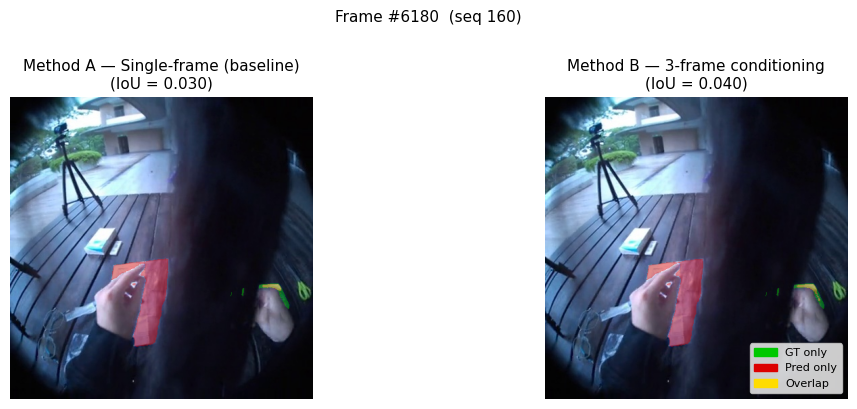

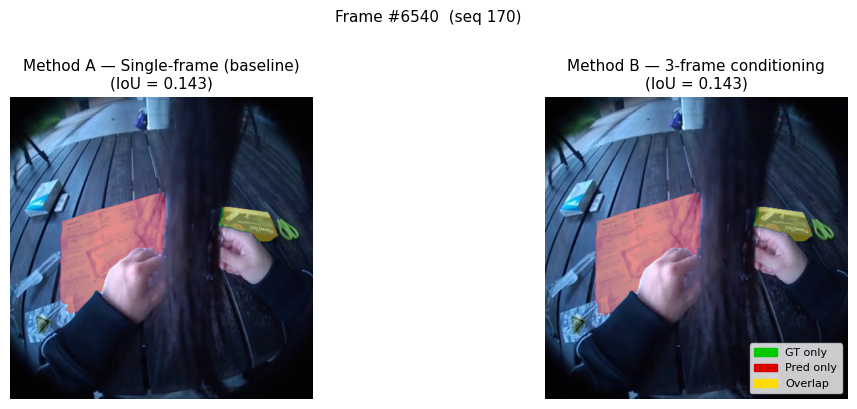

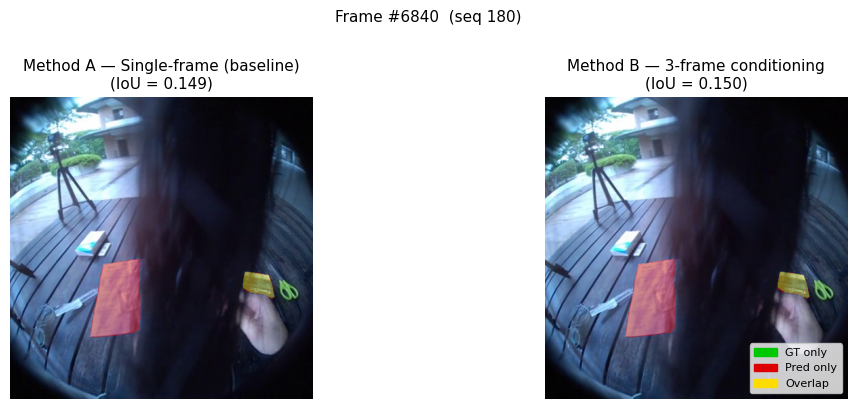

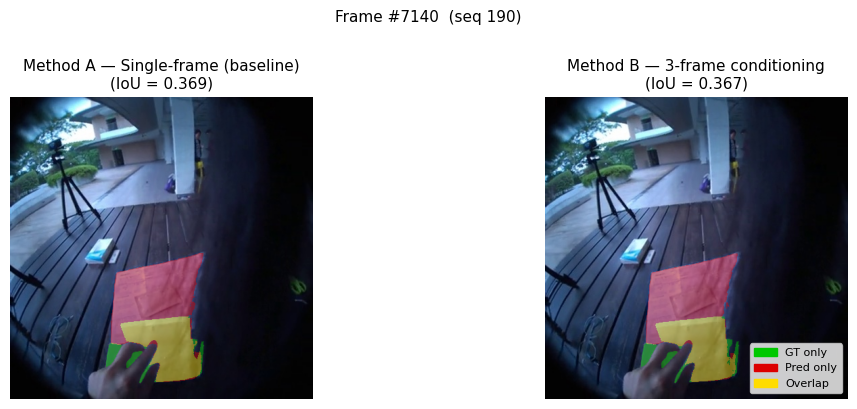

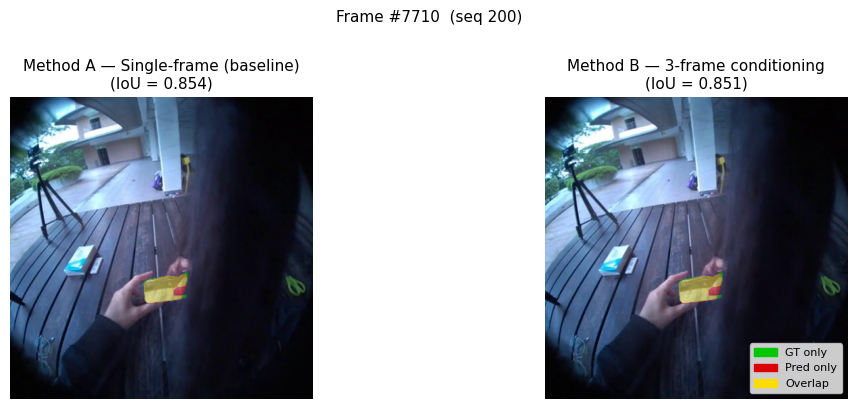

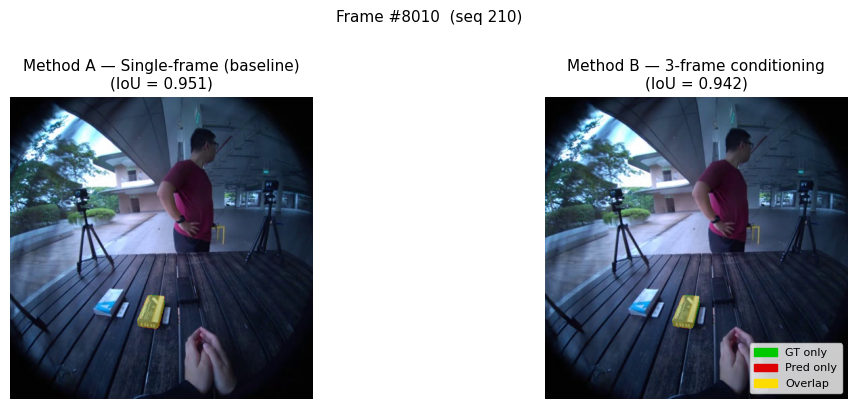

In [75]:
_seed_fns = set(method_b_all_fns) if METHOD_B_EXTRA_FRAME_NUMS is not None else {ref_fn}

for seq_idx in range(0, len(frame_nums), 10):
    fn = frame_nums[seq_idx]
    plot_methods(
        seq_idx=seq_idx,
        frame_num=fn,
        method_results=[
            (label, pred_masks[seq_idx], iou_per_method[label][fn])
            for label, pred_masks in METHODS
        ],
        gt=gt_masks[fn],
        rgb=frames_rgb[fn],
        seed_frame_nums=_seed_fns,
    )

## 9. Clean-up

Remove the temporary video directory and free GPU resources.

In [ ]:
shutil.rmtree(tmp_video_dir, ignore_errors=True)
print(f'Removed {tmp_video_dir}')

for _state in ['inf_state_fwd', 'inf_state_bwd', 'inf_state_b_fwd', 'inf_state_b_bwd']:
    if _state in dir():
        del globals()[_state]
import gc
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()
print('Done.')